# Tracking-by-Clustering — Test Suite & Calibration

This notebook runs every experiment for the report and saves each figure/table to `figs/`.
Run top to bottom. Each **Suite** answers one question, changing **one knob at a time**.

**Suites**
0. Setup & sanity check
1. Calibration of the cost margin $c_{\text{cost}}$
2. Number of objects $K$ — how does it scale?
3. Observation noise $\sigma_{\text{obs}}$ — the main sweep
4. Background clutter — the U-curve (why clutter helps, and when it stops)
5. Object speed — where the motion gate breaks
6. Pre-filter `min_neighbors` — robustness of the noise filter

Everything is deterministic (seeded). Reported metric: **VI on inliers** (lower is better), with the split/merge decomposition where useful.

## Suite 0 — Setup & sanity check
Imports your `tbc` package. Auto-detects whether gating lives in `gating.py` or inside `instance.py`, and whether the canonical GAEC is `gaec_canonical.gaec_full` or `solver.gaec`.

In [1]:
import numpy as np, matplotlib.pyplot as plt, time, io, contextlib, itertools, os
os.makedirs("figs", exist_ok=True)

from tbc.synthesis import SimConfig, generate_dataset
from tbc.solver import variation_of_information

# --- auto-detect the adaptive instance builder ---
try:
    from tbc.gating import build_instance_adaptive as build_instance
    from tbc.gating import estimate_gates_from_dataset
    print("gating: using tbc.gating.build_instance_adaptive")
except ImportError:
    from tbc.instance import build_instance
    from tbc.instance import estimate_gates_from_dataset
    print("gating: using tbc.instance.build_instance")

# --- auto-detect the canonical solver ---
try:
    from tbc.gaec_canonical import gaec_full as _gaec
    print("solver: using tbc.gaec_canonical.gaec_full")
    def solve(inst):
        return _gaec(inst)
except ImportError:
    from tbc.solver import greedy_solve
    print("solver: using tbc.solver.greedy_solve")
    def solve(inst):
        with contextlib.redirect_stdout(io.StringIO()):
            labels, _ = greedy_solve(inst)
        return labels

def build(ds, **kw):
    """Build an instance quietly with sensible defaults."""
    kw.setdefault("cyclic", False)      # time is linear
    kw.setdefault("verbose", False)
    with contextlib.redirect_stdout(io.StringIO()):
        return build_instance(ds, **kw)

def vi_split_merge(ds, labels):
    """VI on inliers, plus split/merge decomposition (in nats)."""
    m = ds.labels >= 0
    T, P = ds.labels[m], labels[m]
    vi = variation_of_information(T, P)
    # decomposition H(T|P) merge, H(P|T) split via contingency
    def cond_entropy(a, b):
        n = len(a); H = 0.0
        for bv in np.unique(b):
            idx = b == bv; pb = idx.mean()
            av = a[idx]; 
            for avv in np.unique(av):
                p = (av==avv).mean()*pb
                if p>0: H -= p*np.log(p/pb)
        return H
    merge = cond_entropy(T, P)   # H(T|P)
    split = cond_entropy(P, T)   # H(P|T)
    return vi, split, merge

def n_large_clusters(labels, thresh=10):
    _, counts = np.unique(labels, return_counts=True)
    return int((counts >= thresh).sum())

# sanity check
ds = generate_dataset(SimConfig())
inst = build(ds)
labels = solve(inst)
vi, split, merge = vi_split_merge(ds, labels)
print(f"\nSanity check (defaults): VI={vi:.3f}  split={split:.3f}  merge={merge:.3f}  "
      f"large clusters={n_large_clusters(labels)}")
print("Setup OK.")

gating: using tbc.instance.build_instance
solver: using tbc.solver.greedy_solve

Sanity check (defaults): VI=0.137  split=0.137  merge=0.000  large clusters=4
Setup OK.


## Suite 1 — Calibrating the cost margin $c_{\text{cost}}$

**Question:** what value of $c_{\text{cost}}$ should we use?
**Knob:** $c_{\text{cost}}$, everything else fixed. Rule fixed in advance: pick the value that minimises the **worst case** across conditions.
**Expected:** a valley — too small fragments objects, too large over-merges. Minimum should be interior to the grid.

  c=0.5: worst=2.770  [2s]
  c=1.0: worst=2.104  [3s]
  c=1.5: worst=1.059  [5s]
  c=2.0: worst=0.220  [7s]
  c=2.25: worst=0.698  [9s]
  c=2.5: worst=1.413  [11s]

SELECTED c_cost = 2.0 (interior: True)


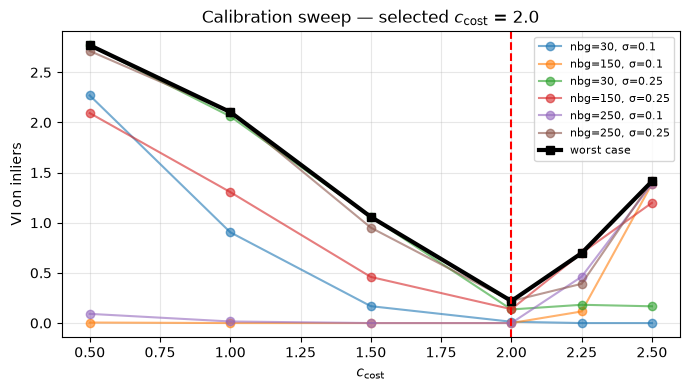

saved figs/calibration_c.pdf


In [2]:
C_GRID = [0.5, 1.0, 1.5, 2.0, 2.25, 2.5]
CONDITIONS = [(30,0.10),(150,0.10),(30,0.25),(150,0.25),(250,0.10),(250,0.25)]
SEEDS = [0,1,2]
REDUCED = dict(n_timesteps=20, n_inliers_per_sphere=10)

VI = np.full((len(C_GRID), len(CONDITIONS), len(SEEDS)), np.nan)
t0=time.time()
for ic,c in enumerate(C_GRID):
    for icond,(nbg,sig) in enumerate(CONDITIONS):
        for js,s in enumerate(SEEDS):
            ds = generate_dataset(SimConfig(n_background=nbg, obs_noise_std=sig, seed=s, **REDUCED))
            inst = build(ds, c_cost_spatial=c, c_cost_motion=c)
            VI[ic,icond,js] = vi_split_merge(ds, solve(inst))[0]
    print(f"  c={c}: worst={np.nanmax(VI[ic].mean(1)):.3f}  [{time.time()-t0:.0f}s]")

mu = VI.mean(2); worst = mu.max(1)
c_star = C_GRID[int(np.argmin(worst))]
print(f"\nSELECTED c_cost = {c_star} (interior: {0<int(np.argmin(worst))<len(C_GRID)-1})")

fig,ax=plt.subplots(figsize=(7,4))
for icond,(nbg,sig) in enumerate(CONDITIONS):
    ax.plot(C_GRID, mu[:,icond], 'o-', lw=1.5, alpha=0.6,
            label=f"nbg={nbg}, σ={sig}")
ax.plot(C_GRID, worst, 's-', lw=3, color='black', label='worst case')
ax.axvline(c_star, ls='--', color='red')
ax.set_xlabel(r"$c_{\rm cost}$"); ax.set_ylabel("VI on inliers")
ax.set_title(f"Calibration sweep — selected $c_{{\\rm cost}}$ = {c_star}")
ax.legend(fontsize=8); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig("figs/calibration_c.pdf"); plt.show()
print("saved figs/calibration_c.pdf")

## Suite 2 — Number of objects $K$

**Question:** how does accuracy scale with scene complexity?
**Knob:** number of spheres, from 2 to 12. Everything else fixed.
**Expected:** VI low for few spheres, rising as $K$ grows (more object boundaries = more chances for the gate to admit a cross-object edge). Runtime rises with $|E|$.
**How to explain failure:** each extra sphere adds boundaries where two objects can be fused; more boundaries, more fusion opportunities.

  K= 2: VI=0.000±0.000  runtime=0.35s  large clusters=2.0
  K= 4: VI=0.175±0.027  runtime=0.43s  large clusters=4.0
  K= 6: VI=0.916±0.079  runtime=0.47s  large clusters=11.3
  K= 8: VI=1.647±0.210  runtime=0.52s  large clusters=26.3
  K=10: VI=2.472±0.114  runtime=0.57s  large clusters=65.3
  K=12: VI=2.769±0.008  runtime=0.66s  large clusters=98.0


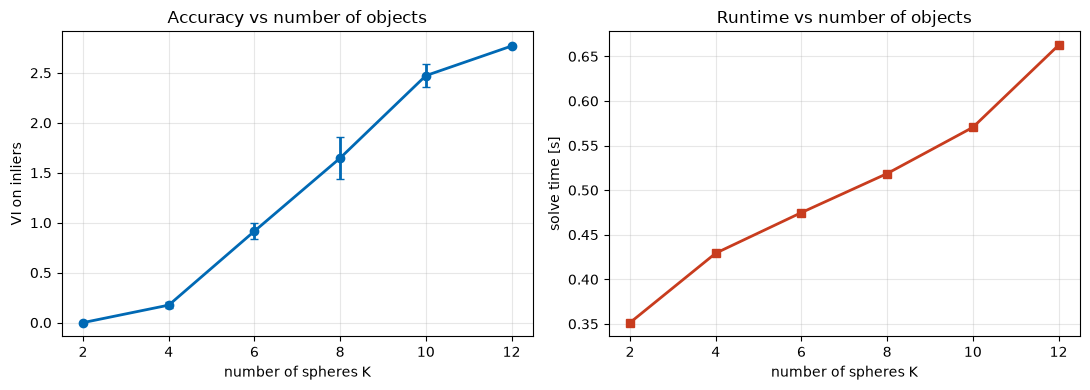


% --- LaTeX table: K sweep ---
\begin{tabular}{cccc}\toprule
$K$ & VI (mean$\pm$std) & runtime [s] & large clusters \\\midrule
2 & $0.000\pm0.000$ & 0.35 & 2.0 \\
4 & $0.175\pm0.027$ & 0.43 & 4.0 \\
6 & $0.916\pm0.079$ & 0.47 & 11.3 \\
8 & $1.647\pm0.210$ & 0.52 & 26.3 \\
10 & $2.472\pm0.114$ & 0.57 & 65.3 \\
12 & $2.769\pm0.008$ & 0.66 & 98.0 \\
\bottomrule\end{tabular}


In [3]:
K_VALUES = [2,4,6,8,10,12]
SEEDS = [0,1,2]
rows=[]
for K in K_VALUES:
    vis, rts, nlarge = [], [], []
    for s in SEEDS:
        ds = generate_dataset(SimConfig(n_spheres=K, seed=s))
        t=time.time(); inst=build(ds); labels=solve(inst); rt=time.time()-t
        vis.append(vi_split_merge(ds,labels)[0]); rts.append(rt)
        nlarge.append(n_large_clusters(labels))
    rows.append((K, np.mean(vis), np.std(vis), np.mean(rts), np.mean(nlarge)))
    print(f"  K={K:2d}: VI={np.mean(vis):.3f}±{np.std(vis):.3f}  "
          f"runtime={np.mean(rts):.2f}s  large clusters={np.mean(nlarge):.1f}")

import numpy as np
K,viM,viS,rtM,nl = map(np.array, zip(*rows))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
a1.errorbar(K,viM,yerr=viS,fmt='o-',lw=2,capsize=3,color='#0069B4')
a1.set_xlabel("number of spheres K"); a1.set_ylabel("VI on inliers")
a1.set_title("Accuracy vs number of objects"); a1.grid(alpha=0.3)
a2.plot(K,rtM,'s-',lw=2,color='#C83C1E')
a2.set_xlabel("number of spheres K"); a2.set_ylabel("solve time [s]")
a2.set_title("Runtime vs number of objects"); a2.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figs/sweep_K.pdf"); plt.show()

# tabla LaTeX
print("\n% --- LaTeX table: K sweep ---")
print(r"\begin{tabular}{cccc}\toprule")
print(r"$K$ & VI (mean$\pm$std) & runtime [s] & large clusters \\\midrule")
for k,vm,vs,rm,n in rows:
    print(f"{k} & ${vm:.3f}\\pm{vs:.3f}$ & {rm:.2f} & {n:.1f} \\\\")
print(r"\bottomrule\end{tabular}")

## Suite 3 — Observation noise $\sigma_{\text{obs}}$ (main sweep)

**Question:** how much observation noise can the method tolerate?
**Knob:** $\sigma_{\text{obs}} \in \{0.05, 0.10, 0.20, 0.40\}$, for both motion models. Fixed $K=4$.
**Expected:** low VI up to 0.20, sharp jump at 0.40 past the $\ln 4 \approx 1.386$ fusion ceiling.
**How to explain failure:** high noise inflates the object clusters until the object-distance mode and the clutter-distance mode overlap; the gate estimator loses the valley it reads and can no longer separate them.

model         σ     VI(mean±std)   split  merge   ARI-ish
ballistic    0.05  0.091±0.017  0.091  0.000
ballistic    0.10  0.185±0.029  0.185  0.000
ballistic    0.20  0.400±0.025  0.398  0.002
ballistic    0.40  1.386±0.166  0.781  0.605
random walk  0.05  0.086±0.015  0.086  0.000
random walk  0.10  0.175±0.027  0.175  0.000
random walk  0.20  0.382±0.021  0.379  0.003
random walk  0.40  1.507±0.029  0.760  0.746


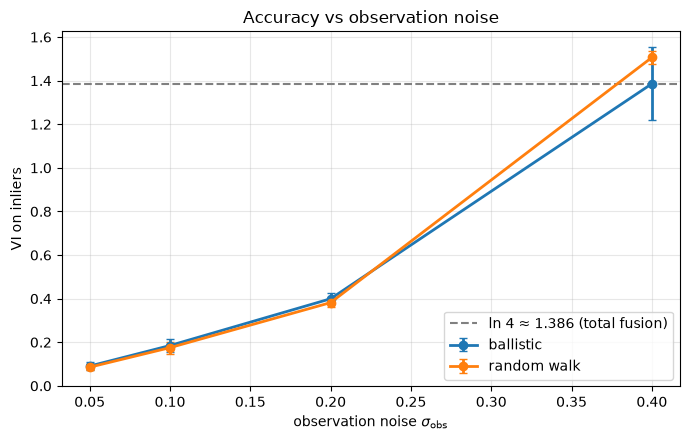

saved figs/sweep_noise.pdf


In [4]:
SIGMAS = [0.05, 0.10, 0.20, 0.40]
MODELS = {"ballistic": 0.0, "random walk": 0.05}
SEEDS = [0,1,2]
ln4 = np.log(4)
results = {}
print("model         σ     VI(mean±std)   split  merge   ARI-ish")
for name, smot in MODELS.items():
    curve=[]
    for sig in SIGMAS:
        vis, sp, mg = [], [], []
        for s in SEEDS:
            ds = generate_dataset(SimConfig(n_spheres=4, obs_noise_std=sig,
                                            motion_noise_std=smot, seed=s))
            labels = solve(build(ds))
            v,spl,mrg = vi_split_merge(ds, labels); vis.append(v); sp.append(spl); mg.append(mrg)
        curve.append((sig, np.mean(vis), np.std(vis), np.mean(sp), np.mean(mg)))
        print(f"{name:12s} {sig:.2f}  {np.mean(vis):.3f}±{np.std(vis):.3f}  "
              f"{np.mean(sp):.3f}  {np.mean(mg):.3f}")
    results[name]=np.array(curve)

fig,ax=plt.subplots(figsize=(7,4.5))
for name,cur in results.items():
    ax.errorbar(cur[:,0],cur[:,1],yerr=cur[:,2],fmt='o-',lw=2,capsize=3,label=name)
ax.axhline(ln4, ls='--', color='gray', label=f'ln 4 ≈ {ln4:.3f} (total fusion)')
ax.set_xlabel(r"observation noise $\sigma_{\rm obs}$"); ax.set_ylabel("VI on inliers")
ax.set_title("Accuracy vs observation noise"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figs/sweep_noise.pdf"); plt.show()
print("saved figs/sweep_noise.pdf")

## Suite 4 — Background clutter: the U-curve

**Question:** does the method need background clutter, and how much?
**Knob:** clutter points per frame $\in \{0, 10, 25, 50, 100, 200\}$. Fixed $\sigma=0.10$.
**Expected:** a U-shape. **Zero** clutter is *terrible* (estimator sees only short distances → gate too tight → objects fragment). Too **much** clutter is also bad (clutter becomes the majority → median breaks → percolation). Best in the middle.
**How to explain:** the gate calibrates by finding a valley between the object-distance mode and the clutter-distance mode; it needs *both* modes present and needs objects to stay the majority.

  clutter=  0: VI=4.701±0.037  split=4.701  merge=0.000  large=69.7
  clutter= 10: VI=3.555±0.051  split=3.555  merge=0.000  large=46.0
  clutter= 25: VI=1.572±0.130  split=1.572  merge=0.000  large=11.0
  clutter= 50: VI=0.175±0.027  split=0.175  merge=0.000  large=4.0
  clutter=100: VI=0.000±0.000  split=0.000  merge=0.000  large=4.3
  clutter=200: VI=0.000±0.000  split=0.000  merge=0.000  large=224.3


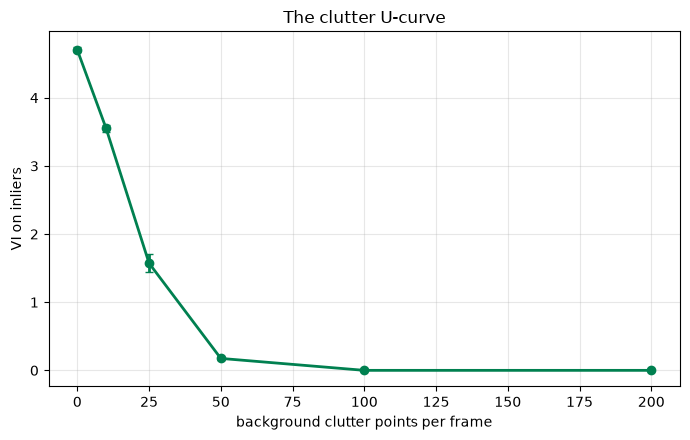


% --- LaTeX table: clutter U-curve ---
\begin{tabular}{cccccc}\toprule
clutter/frame & VI & split & merge & large clusters \\\midrule
0 & 4.701 & 4.701 & 0.000 & 69.7 \\
10 & 3.555 & 3.555 & 0.000 & 46.0 \\
25 & 1.572 & 1.572 & 0.000 & 11.0 \\
50 & 0.175 & 0.175 & 0.000 & 4.0 \\
100 & 0.000 & 0.000 & 0.000 & 4.3 \\
200 & 0.000 & 0.000 & 0.000 & 224.3 \\
\bottomrule\end{tabular}


In [5]:
CLUTTER = [0, 10, 25, 50, 100, 200]
SEEDS = [0,1,2]
rows=[]
for nbg in CLUTTER:
    vis, sp, mg, nl = [], [], [], []
    for s in SEEDS:
        ds = generate_dataset(SimConfig(n_spheres=4, n_background=nbg,
                                        obs_noise_std=0.10, seed=s))
        labels = solve(build(ds))
        v,spl,mrg = vi_split_merge(ds,labels)
        vis.append(v); sp.append(spl); mg.append(mrg); nl.append(n_large_clusters(labels))
    rows.append((nbg,np.mean(vis),np.std(vis),np.mean(sp),np.mean(mg),np.mean(nl)))
    print(f"  clutter={nbg:3d}: VI={np.mean(vis):.3f}±{np.std(vis):.3f}  "
          f"split={np.mean(sp):.3f}  merge={np.mean(mg):.3f}  large={np.mean(nl):.1f}")

nbg,vm,vs,spl,mrg,nl = map(np.array, zip(*rows))
fig,ax=plt.subplots(figsize=(7,4.5))
ax.errorbar(nbg,vm,yerr=vs,fmt='o-',lw=2,capsize=3,color='#008050')
ax.set_xlabel("background clutter points per frame"); ax.set_ylabel("VI on inliers")
ax.set_title("The clutter U-curve"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figs/clutter_ucurve.pdf"); plt.show()

print("\n% --- LaTeX table: clutter U-curve ---")
print(r"\begin{tabular}{cccccc}\toprule")
print(r"clutter/frame & VI & split & merge & large clusters \\\midrule")
for n,v,_,sp,mg,l in rows:
    print(f"{n} & {v:.3f} & {sp:.3f} & {mg:.3f} & {l:.1f} \\\\")
print(r"\bottomrule\end{tabular}")

## Suite 5 — Object speed: where the motion gate breaks

**Question:** how fast can objects move before tracks fragment?
**Knob:** sphere speed. Fixed $K=4$, moderate noise.
**Expected:** low VI at low speed, rising when displacement-per-step exceeds the clutter spacing.
**How to explain failure:** the motion gate assumes small per-step displacement. When an object moves so far between frames that its next detection lands beyond the gate, the gate no longer recognises it as the same object, and the trajectory splits across frames.

speed parameter in SimConfig: speed
  speed=0.02: VI=0.342±0.033  split=0.342
  speed=0.05: VI=0.344±0.030  split=0.344
  speed=0.10: VI=0.347±0.030  split=0.347
  speed=0.20: VI=0.326±0.025  split=0.326
  speed=0.40: VI=0.295±0.023  split=0.295
  speed=0.80: VI=0.244±0.015  split=0.244


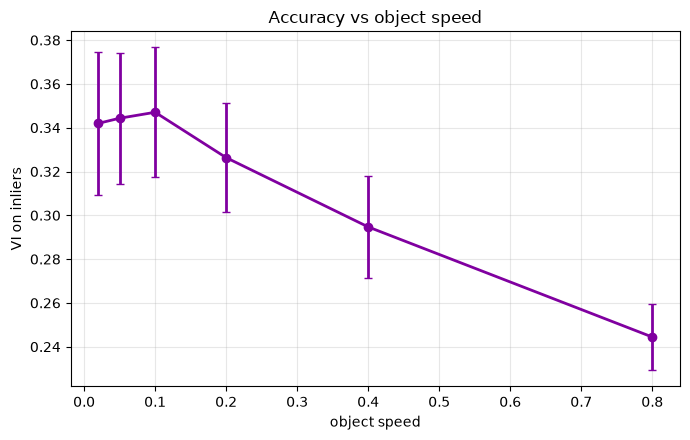

In [6]:
# NOTE: adjust the parameter name if your SimConfig uses a different one than "speed".
import inspect
speed_param = "speed" if "speed" in inspect.signature(SimConfig).parameters else None
print("speed parameter in SimConfig:", speed_param)

if speed_param:
    SPEEDS = [0.02, 0.05, 0.10, 0.20, 0.40, 0.80]
    SEEDS = [0,1,2]
    rows=[]
    for v in SPEEDS:
        vis, sp = [], []
        for s in SEEDS:
            ds = generate_dataset(SimConfig(n_spheres=4, obs_noise_std=0.10,
                                            **{speed_param:v}, seed=s))
            labels = solve(build(ds))
            vv,spl,mrg = vi_split_merge(ds,labels); vis.append(vv); sp.append(spl)
        rows.append((v,np.mean(vis),np.std(vis),np.mean(sp)))
        print(f"  speed={v:.2f}: VI={np.mean(vis):.3f}±{np.std(vis):.3f}  split={np.mean(sp):.3f}")
    spd,vm,vs,spl = map(np.array, zip(*rows))
    fig,ax=plt.subplots(figsize=(7,4.5))
    ax.errorbar(spd,vm,yerr=vs,fmt='o-',lw=2,capsize=3,color='#8000A0')
    ax.set_xlabel("object speed"); ax.set_ylabel("VI on inliers")
    ax.set_title("Accuracy vs object speed"); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig("figs/sweep_speed.pdf"); plt.show()
else:
    print("Could not find a 'speed' parameter — check SimConfig and set speed_param manually.")

## Suite 6 — Pre-filter `min_neighbors`

**Question:** how sensitive is the method to the noise pre-filter threshold?
**Knob:** `min_neighbors` $\in \{1,2,3,5,8\}$, at two noise levels.
**Expected:** too low doesn't filter clutter; too high starts dropping real inliers (split error rises). Justifies the choice of 3.

In [7]:
MN = [1,2,3,5,8]
for sig in [0.10, 0.20]:
    print(f"\nσ = {sig}")
    for mn in MN:
        vis=[]
        for s in [0,1,2]:
            ds = generate_dataset(SimConfig(n_spheres=4, obs_noise_std=sig, seed=s))
            labels = solve(build(ds, min_neighbors=mn))
            vis.append(vi_split_merge(ds,labels)[0])
        print(f"  min_neighbors={mn}: VI={np.mean(vis):.3f}±{np.std(vis):.3f}")


σ = 0.1
  min_neighbors=1: VI=0.120±0.024
  min_neighbors=2: VI=0.138±0.016
  min_neighbors=3: VI=0.175±0.027
  min_neighbors=5: VI=0.313±0.023
  min_neighbors=8: VI=0.749±0.039

σ = 0.2
  min_neighbors=1: VI=0.314±0.024
  min_neighbors=2: VI=0.340±0.028
  min_neighbors=3: VI=0.382±0.021
  min_neighbors=5: VI=0.571±0.009
  min_neighbors=8: VI=1.169±0.013


## Suite 7 — Inlier density $n_{\text{in}}$

**Question:** how many detections per object are needed for reliable tracking?
**Knob:** inliers per sphere per frame $\in \{5, 10, 15, 20, 30\}$. Fixed $K=4$, moderate noise.
**Expected:** sparse objects (few detections) are easier for the core-point filter to strand as singletons, so VI rises as $n_{\text{in}}$ drops. Denser objects should track cleanly.
**How to explain failure:** with few inliers, a real object looks thin — points fall below the `min_neighbors` threshold of the pre-filter and are dropped as clutter, fragmenting the track (split error).

  n_in= 5: VI=0.824±0.000  split=0.000  merge=0.824  large=42.0
  n_in=10: VI=0.000±0.000  split=0.000  merge=0.000  large=4.0
  n_in=15: VI=0.016±0.008  split=0.016  merge=0.000  large=4.0
  n_in=20: VI=0.175±0.027  split=0.175  merge=0.000  large=4.0
  n_in=30: VI=0.942±0.098  split=0.942  merge=0.000  large=7.3


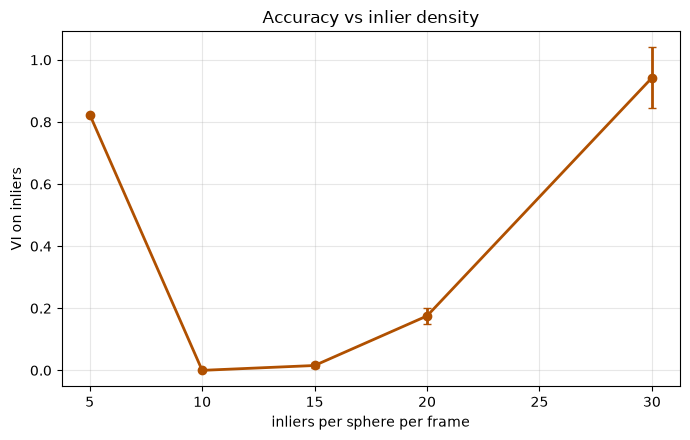


% --- LaTeX table: inlier density ---
\begin{tabular}{ccccc}\toprule
$n_{\rm in}$ & VI (mean$\pm$std) & split & merge & large clusters \\\midrule
5 & $0.824\pm0.000$ & 0.000 & 0.824 & 42.0 \\
10 & $0.000\pm0.000$ & 0.000 & 0.000 & 4.0 \\
15 & $0.016\pm0.008$ & 0.016 & 0.000 & 4.0 \\
20 & $0.175\pm0.027$ & 0.175 & 0.000 & 4.0 \\
30 & $0.942\pm0.098$ & 0.942 & 0.000 & 7.3 \\
\bottomrule\end{tabular}


In [8]:
NIN = [5, 10, 15, 20, 30]
SEEDS = [0, 1, 2]
rows = []
for nin in NIN:
    vis, sp, mg, nl = [], [], [], []
    for s in SEEDS:
        ds = generate_dataset(SimConfig(n_spheres=4, n_inliers_per_sphere=nin,
                                        obs_noise_std=0.10, seed=s))
        labels = solve(build(ds))
        v, spl, mrg = vi_split_merge(ds, labels)
        vis.append(v); sp.append(spl); mg.append(mrg); nl.append(n_large_clusters(labels))
    rows.append((nin, np.mean(vis), np.std(vis), np.mean(sp), np.mean(mg), np.mean(nl)))
    print(f"  n_in={nin:2d}: VI={np.mean(vis):.3f}±{np.std(vis):.3f}  "
          f"split={np.mean(sp):.3f}  merge={np.mean(mg):.3f}  large={np.mean(nl):.1f}")

nin, vm, vs, spl, mrg, nl = map(np.array, zip(*rows))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(nin, vm, yerr=vs, fmt='o-', lw=2, capsize=3, color='#B05000')
ax.set_xlabel("inliers per sphere per frame"); ax.set_ylabel("VI on inliers")
ax.set_title("Accuracy vs inlier density"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figs/sweep_inliers.pdf"); plt.show()

print("\n% --- LaTeX table: inlier density ---")
print(r"\begin{tabular}{ccccc}\toprule")
print(r"$n_{\rm in}$ & VI (mean$\pm$std) & split & merge & large clusters \\\midrule")
for n, v, vsd, sp_, mg_, l in rows:
    print(f"{n} & ${v:.3f}\\pm{vsd:.3f}$ & {sp_:.3f} & {mg_:.3f} & {l:.1f} \\\\")
print(r"\bottomrule\end{tabular}")

## Done

All figures are in `figs/`. The LaTeX tables printed above can be pasted directly into the report.
Remember: **report what you measured, not what you expected.** A well-explained failure is worth as much as a success.